In [1]:
from PIL import Image, ImageDraw 

In [6]:
def UpscalingImage2x(image):
    width = image.size[0] #Определяем ширину. 
    height = image.size[1] #Определяем высоту. 
    
    up_image = Image.new(mode="RGB", size=(width * 2, height * 2))
    draw = ImageDraw.Draw(up_image) #Создаем инструмент для рисования. 
    	
    orig_pix = image.load() #Выгружаем значения пикселей.
    
    for i in range(0, height):
        for j in range(0, width):
            pixel = orig_pix[i, j]
            
            for k in range(0, 2):
                for m in range(0, 2):
                    draw.point((2 * i + k, 2 * j + m), pixel)
                    
    return up_image

In [34]:
image = Image.open("./data/test_img.jpg") #Открываем изображение. 
image.size

(736, 981)

In [35]:
up_image = UpscalingImage2x(image)
up_image.show()

up_image.size

IndexError: image index out of range

In [ ]:
def UpscalingImage2xSmoothing(image):
    width = image.size[0] #Определяем ширину. 
    height = image.size[1] #Определяем высоту. 
    
    up_image = Image.new(mode="RGB", size=(width * 2, height * 2))
    draw = ImageDraw.Draw(up_image) #Создаем инструмент для рисования. 
    	
    orig_pix = image.load() #Выгружаем значения пикселей.
    
    for i in range(0, height - 1):
        for j in range(0, width - 1):
            pixel = orig_pix[i, j]
            
            draw.point((2 * i, 2 * j), pixel)
                    
    

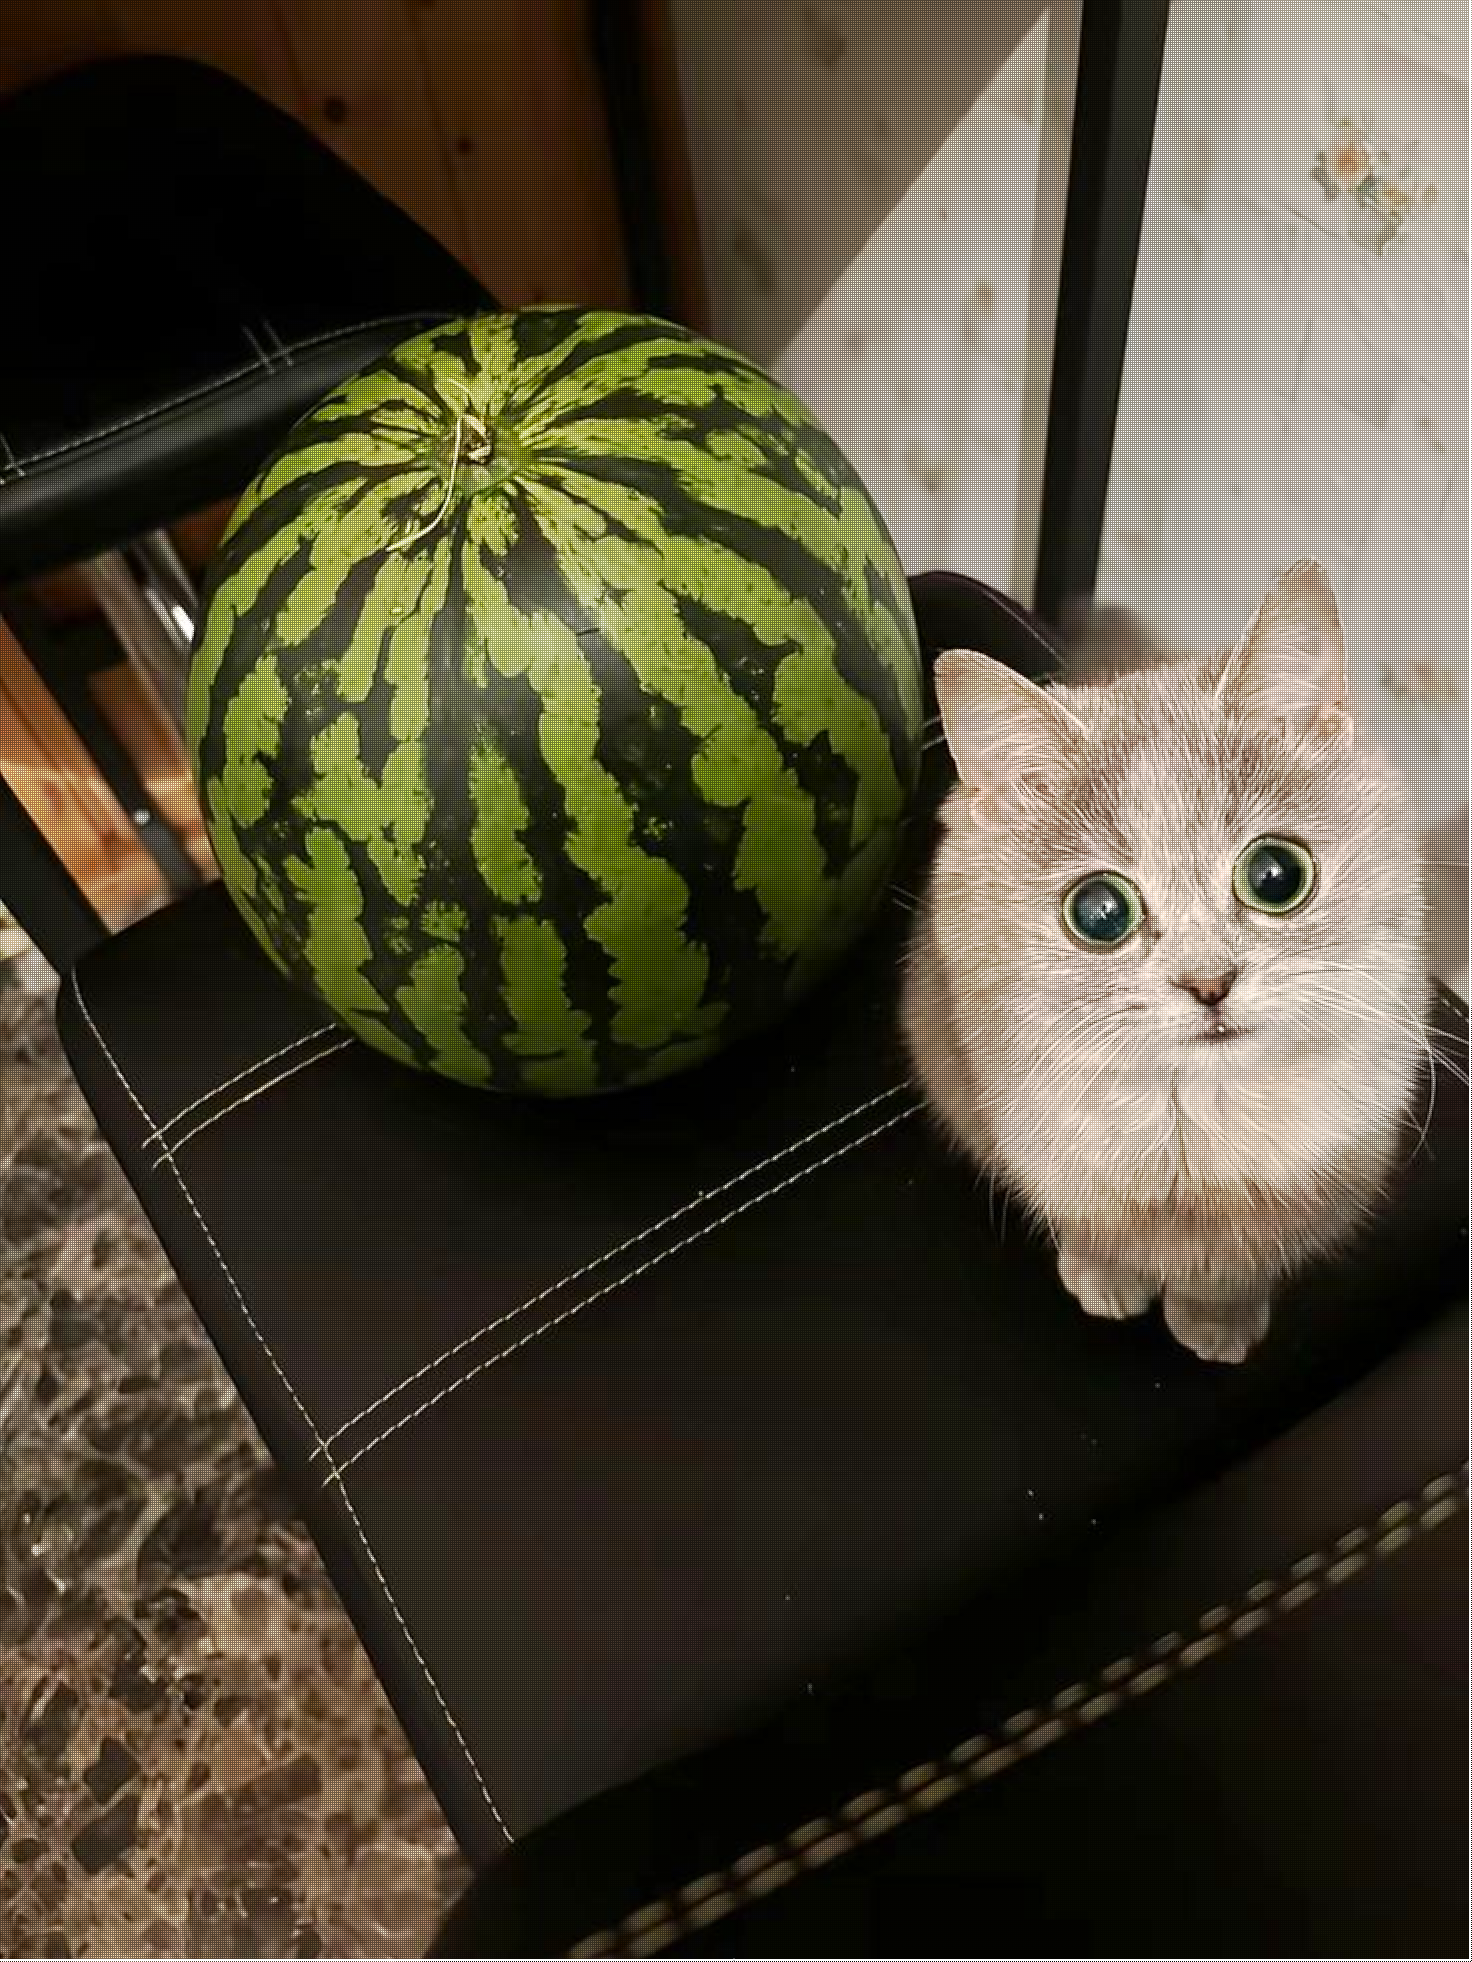

In [54]:
width = image.size[0] #Определяем ширину. 
height = image.size[1] #Определяем высоту. 

up_image = Image.new(mode="RGB", size=(width * 2, height * 2), color=(255, 255, 255))
draw = ImageDraw.Draw(up_image) #Создаем инструмент для рисования. 
	
orig_pix = image.load() #Выгружаем значения пикселей.

# Заполнение до последнего столбца
for i in range(0, height - 1):
    for j in range(0, width - 1):
        pixel = orig_pix[j,i]
        draw.point((2 * j, 2 * i), pixel)



# заполнение последних строк и столбцов
for i in range(height):
    pixel = orig_pix[width - 1, i]
    draw.point((2 * width - 1, 2 * i), pixel)
    
for i in range(width):
    pixel = orig_pix[i, height - 1,]
    draw.point((2*i, 2 * height - 1), pixel)

pixels = up_image.load()
# Среднее по вертикали
for j in range(1, 2 * height - 3, 2):
    for i in range(0, 2 * width - 3, 2):
        pixel_u = pixels[i, j - 1]
        pixel_d = pixels[i, j + 1]
        
        av_pix = [(pixel_u[k] + pixel_d[k]) // 2 for k in range(len(pixel_u))]
        draw.point((i, j), (av_pix[0], av_pix[1], av_pix[2]))
        
# Среднее по горизонтали
for j in range(0, 2 * height - 3, 2):
    for i in range(1, 2 * width - 3, 2):
        pixel_l = pixels[i - 1, j]
        pixel_r = pixels[i + 1, j]
        av_pix = [(pixel_l[i] + pixel_r[i]) // 2 for i in range(len(pixel_l))]
        draw.point((i, j), (av_pix[0], av_pix[1], av_pix[2]))
        
#up_image.show()
        
for j in range(1, 2 * height - 3, 2):
    for i in range(1, 2 * width - 3, 2):
        pixel_l = pixels[i - 1, j]
        pixel_t = pixels[i, j + 1]
        pixel_r = pixels[i + 1, j]
        pixel_d = pixels[i, j - 1]
        
        av_pix = [
            (
                pixel_l[i] + 
                pixel_r[i] + 
                pixel_t[i] + 
                pixel_d[i]
            ) // 2 for i in range(len(pixel_l))]
        draw.point((i, j), (av_pix[0], av_pix[1], av_pix[2]))
        
# создадим мнимый столбец
im_comlumn = []
for j in range(2 * height):
    av_pix = [255, 255, 255]
    if j % 2 == 0:
        pixel_l = pixels[width - 2, j - 1]
        pixel_r = pixels[width - 2, j + 1]
        av_pix = [(pixel_l[i] + pixel_r[i]) // 2 for i in range(len(pixel_l))]
        
    im_comlumn.append(av_pix)

im_row = []
for j in range(2 * width):
    
    av_pix = [255, 255, 255]
    
    if j % 2 == 0:
        pixel_l = pixels[j - 1, height - 2]
        pixel_r = pixels[j + 1, height - 2]
        av_pix = [(pixel_l[i] + pixel_r[i]) // 2 for i in range(len(pixel_l))]
        
    im_row.append(av_pix)



        
# Среднее по горизонтали
for j in range(0, 2 * height, 2):
    
    pixel_ll = pixels[width - 4, j]
    pixel_lr = im_comlumn[j]
    
    pixel_rr = pixels[width - 1, j]
    pixel_rl = im_comlumn[j]
    
    
    av_pix = [(pixel_ll[i] + pixel_lr[i]) // 2 for i in range(len(pixel_l))]
    draw.point((width - 3, j), (av_pix[0], av_pix[1], av_pix[2]))
    av_pix = [(pixel_rr[i] + pixel_rl[i]) // 2 for i in range(len(pixel_l))]
    draw.point((width - 2, j), (av_pix[0], av_pix[1], av_pix[2]))
    
up_image